# FAILSAFE — Early Student Failure Risk Detection System

**Team:** Prem Kadam · Bhavit · Krishna Jain
**Institution:** IIT Guwahati
**Dataset:** UCI Student Performance Dataset (Math + Portuguese)

---

### Pipeline

| Step | Description |
|---|---|
| 1 | Setup & Imports |
| 2 | Data Loading & Merging |
| 3 | Exploratory Data Analysis |
| 4 | Feature Engineering — `at_risk = 1 if G3 < 10 else 0` |
| 5 | Train / Test Split — **before any encoding (prevents leakage)** |
| 6 | Preprocessing — LabelEncoders fit on train set only |
| 7 | Baseline XGBoost |
| 8 | Optuna Tuning — 50 trials, 5-fold CV on train only |
| 9 | Final Model + Overfitting Check |
| 10 | SHAP Explainability — Global + Per-Student |
| 11 | Personalised Intervention Plan Generator |
| 12 | Model Export |

> **Data Leakage Prevention:** Train/test split happens before any preprocessing. LabelEncoders are fit on the train set only and applied to the test set via `.transform()`. G3 (the source of the target label) is dropped immediately. Optuna tuning uses cross-validation on the train set only — the test set is never seen during tuning.

In [1]:
!pip install xgboost shap optuna scikit-learn pandas numpy matplotlib seaborn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.1 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import pickle
import io

from google.colab import files
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
# Upload student-mat.csv and student-por.csv when prompted
print("Upload student-mat.csv and student-por.csv")
uploaded = files.upload()

mat = pd.read_csv(io.BytesIO(uploaded['student-mat.csv']), sep=';')
por = pd.read_csv(io.BytesIO(uploaded['student-por.csv']), sep=';')

df = pd.concat([mat, por], ignore_index=True).drop_duplicates().reset_index(drop=True)

print(f"Math       : {len(mat)} rows")
print(f"Portuguese : {len(por)} rows")
print(f"Combined   : {df.shape[0]} rows  |  {df.shape[1]} columns")
print(f"Null values: {df.isnull().sum().sum()}")
df.head()

Upload student-mat.csv and student-por.csv


Saving student-mat.csv to student-mat.csv
Saving student-por.csv to student-por.csv
Math       : 395 rows
Portuguese : 649 rows
Combined   : 1044 rows  |  33 columns
Null values: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


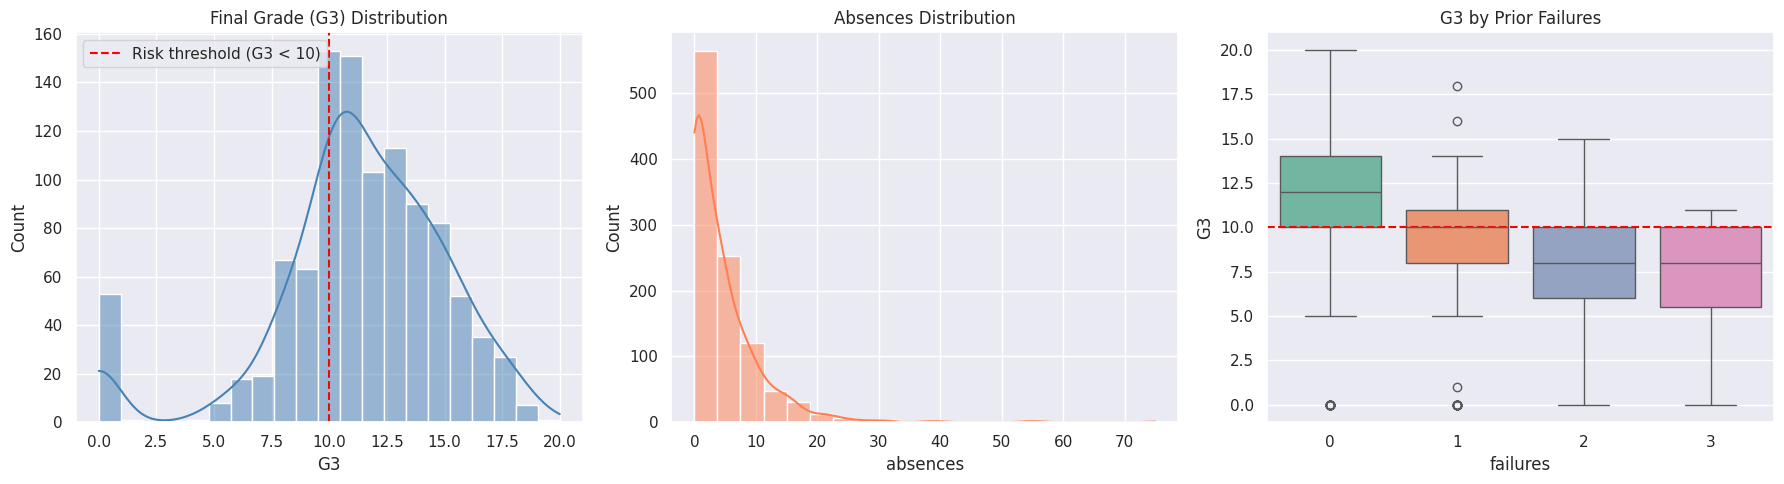

At-Risk students (G3 < 10) : 230 (22.0%)
Safe    students (G3 >= 10): 814 (78.0%)


In [4]:
# Grade distribution, absences, and failures vs G3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['G3'], bins=21, ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Risk threshold (G3 < 10)')
axes[0].set_title('Final Grade (G3) Distribution')
axes[0].legend()

sns.histplot(df['absences'], bins=20, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Absences Distribution')

sns.boxplot(x='failures', y='G3', data=df, ax=axes[2], palette='Set2')
axes[2].axhline(y=10, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('G3 by Prior Failures')

plt.tight_layout()
plt.show()

n_atrisk = (df['G3'] < 10).sum()
print(f"At-Risk students (G3 < 10) : {n_atrisk} ({n_atrisk / len(df) * 100:.1f}%)")
print(f"Safe    students (G3 >= 10): {len(df) - n_atrisk} ({(len(df) - n_atrisk) / len(df) * 100:.1f}%)")

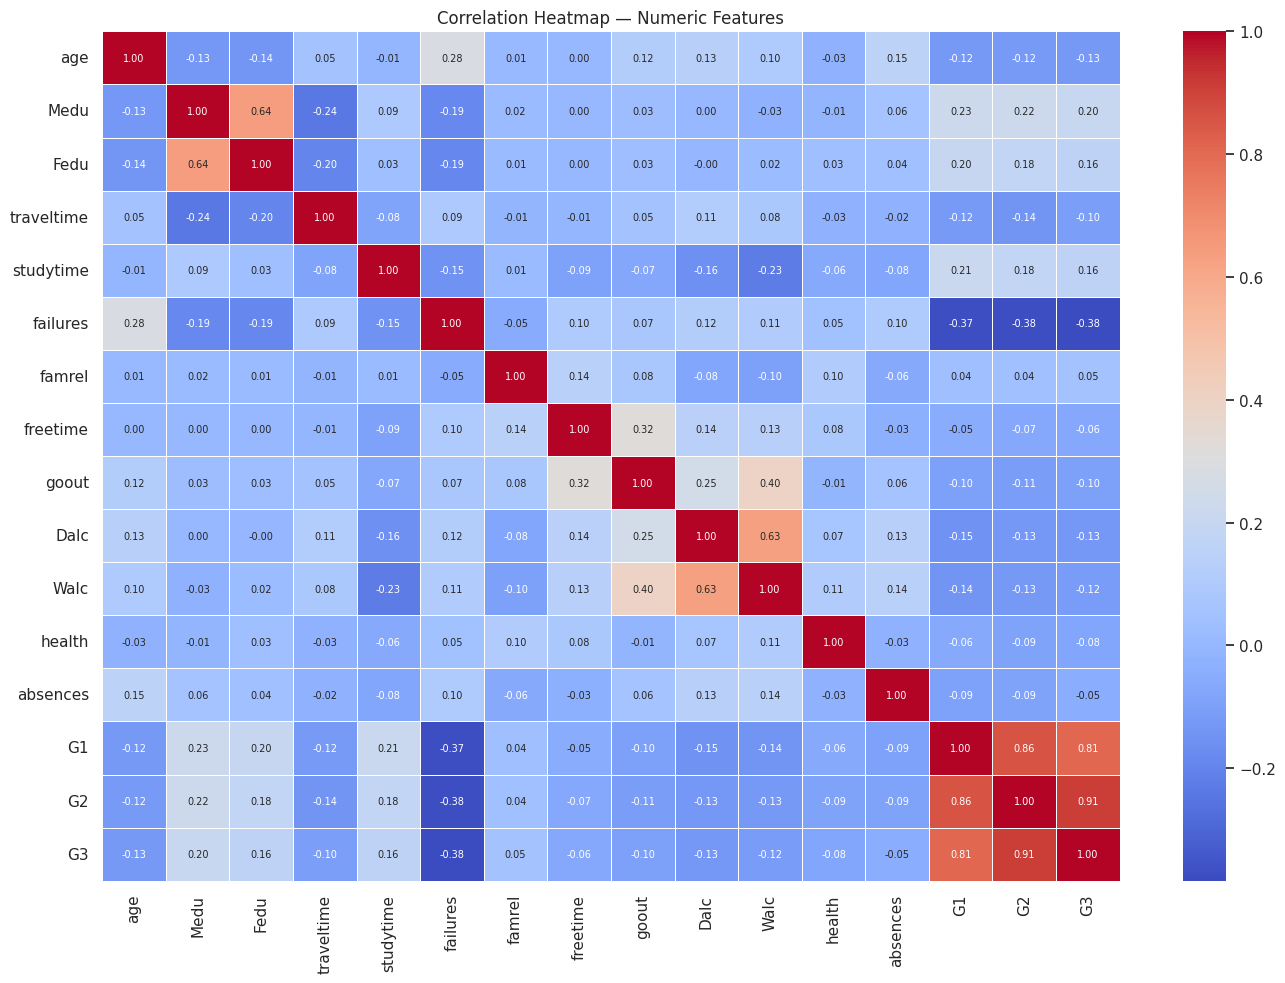

In [5]:
# Correlation heatmap — numeric features only
num_df = df.select_dtypes(include='number')
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

In [6]:
# G3 is the direct source of the label — must be dropped to prevent target leakage.
# G1 and G2 are Period 1 and 2 grades collected BEFORE G3 — they are valid features.

df['at_risk'] = (df['G3'] < 10).astype(int)
df = df.drop(columns=['G3'])

X = df.drop(columns=['at_risk'])
y = df['at_risk']

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print()
print("Class Distribution:")
print(y.value_counts().rename({0: 'Safe (0)', 1: 'At-Risk (1)'}).to_string())

Features : 32
Samples  : 1044

Class Distribution:
at_risk
Safe (0)       814
At-Risk (1)    230


In [7]:
# CRITICAL: Train/test split happens BEFORE any encoding.
# Fitting encoders on full data before split leaks test distribution into the encoder.
# stratify=y ensures both splits have the same at_risk ratio.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")
print()
print("Train class distribution:")
print(y_train.value_counts().rename({0: 'Safe', 1: 'At-Risk'}).to_string())
print()
print("Test class distribution:")
print(y_test.value_counts().rename({0: 'Safe', 1: 'At-Risk'}).to_string())

Train : 835 rows
Test  : 209 rows

Train class distribution:
at_risk
Safe       651
At-Risk    184

Test class distribution:
at_risk
Safe       163
At-Risk     46


In [8]:
# LabelEncoder is fit ONLY on X_train.
# X_test uses .transform() only — never .fit_transform() — to prevent leakage.

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
encoders = {}

X_train = X_train.copy()
X_test  = X_test.copy()

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    encoders[col] = le

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = round(neg / pos, 4)

print(f"Categorical columns encoded : {len(cat_cols)}")
print(f"  {cat_cols}")
print()
print(f"Negative (Safe)    : {neg}")
print(f"Positive (At-Risk) : {pos}")
print(f"scale_pos_weight   : {scale_pos_weight}")

Categorical columns encoded : 17
  ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Negative (Safe)    : 651
Positive (At-Risk) : 184
scale_pos_weight   : 3.538


In [9]:
baseline = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0
)
baseline.fit(X_train, y_train, verbose=False)

y_pred_base  = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("          BASELINE XGBoost RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_base, target_names=['Safe', 'At-Risk']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_base):.4f}")

          BASELINE XGBoost RESULTS
              precision    recall  f1-score   support

        Safe       0.94      0.91      0.93       163
     At-Risk       0.73      0.80      0.76        46

    accuracy                           0.89       209
   macro avg       0.83      0.86      0.85       209
weighted avg       0.90      0.89      0.89       209

ROC-AUC : 0.9619


In [10]:
# Optuna tunes over 50 trials using 5-fold stratified CV on the train set only.
# The test set is NEVER seen during hyperparameter search.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 10.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight' : scale_pos_weight,
        'random_state'     : 42,
        'eval_metric'      : 'logloss',
        'verbosity'        : 0,
    }
    model  = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : 42,
    'eval_metric'      : 'logloss',
    'verbosity'        : 0,
})

print(f"Best F1 (CV on train): {study.best_value:.4f}")
print()
print("Best hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best F1 (CV on train): 0.8285

Best hyperparameters:
  n_estimators: 444
  max_depth: 4
  learning_rate: 0.12165025234971262
  subsample: 0.6260773120732186
  colsample_bytree: 0.6549887331545162
  reg_alpha: 3.4397537139997874
  reg_lambda: 9.188562195842271
  min_child_weight: 8
  scale_pos_weight: 3.538
  random_state: 42
  eval_metric: logloss
  verbosity: 0


             OVERFITTING CHECK
Metric               Train       Test        Gap
-------------------------------------------------------
F1 Score            0.9010     0.7723     0.1287
Accuracy            0.9521     0.8900     0.0621
ROC-AUC             0.9919     0.9603     0.0316
-------------------------------------------------------
Possible overfitting — F1 gap >= 0.10

        FINAL MODEL — TEST SET RESULTS
              precision    recall  f1-score   support

        Safe       0.95      0.90      0.93       163
     At-Risk       0.71      0.85      0.77        46

    accuracy                           0.89       209
   macro avg       0.83      0.87      0.85       209
weighted avg       0.90      0.89      0.89       209

ROC-AUC : 0.9603


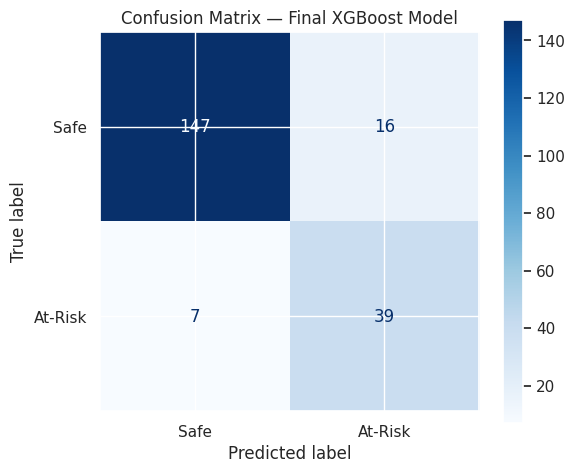

In [11]:
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train, verbose=False)

y_pred_train = final_model.predict(X_train)
y_pred_test  = final_model.predict(X_test)
y_proba_test = final_model.predict_proba(X_test)[:, 1]

# ── Overfitting check ─────────────────────────────────────────────────────
train_f1  = f1_score(y_train, y_pred_train)
test_f1   = f1_score(y_test,  y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)
train_auc = roc_auc_score(y_train, final_model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  y_proba_test)

print("=" * 55)
print("             OVERFITTING CHECK")
print("=" * 55)
print(f"{'Metric':<15} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("-" * 55)
print(f"{'F1 Score':<15} {train_f1:>10.4f} {test_f1:>10.4f} {abs(train_f1 - test_f1):>10.4f}")
print(f"{'Accuracy':<15} {train_acc:>10.4f} {test_acc:>10.4f} {abs(train_acc - test_acc):>10.4f}")
print(f"{'ROC-AUC':<15} {train_auc:>10.4f} {test_auc:>10.4f} {abs(train_auc - test_auc):>10.4f}")
print("-" * 55)
gap    = abs(train_f1 - test_f1)
status = "Model is well-generalised (F1 gap < 0.10)" if gap < 0.10 else "Possible overfitting — F1 gap >= 0.10"
print(status)

print()
print("=" * 55)
print("        FINAL MODEL — TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_test, target_names=['Safe', 'At-Risk']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_test):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Safe', 'At-Risk'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Final XGBoost Model')
plt.tight_layout()
plt.show()

Global SHAP Feature Importance:


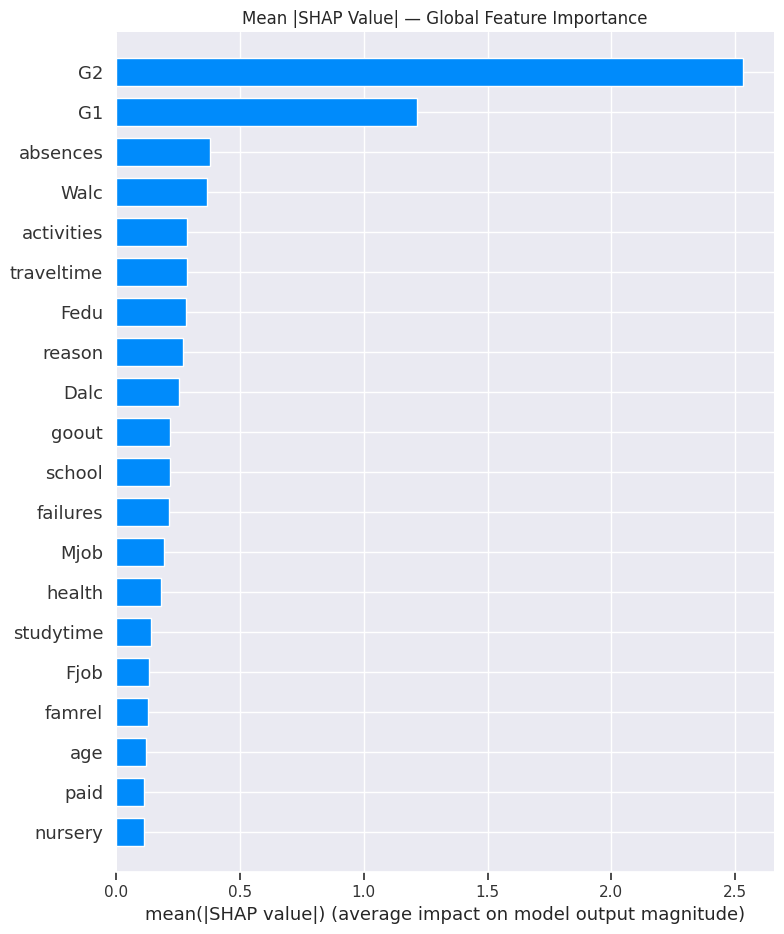

SHAP Beeswarm — Feature Impact Direction:


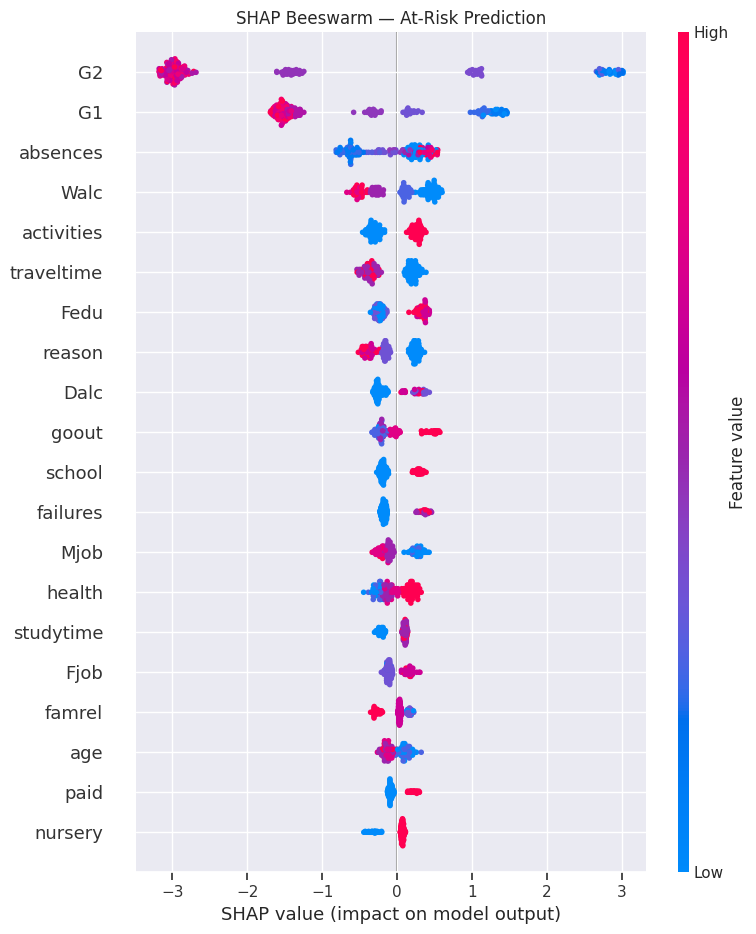

Per-Student SHAP — Student #0  |  Risk Score: 94.4%


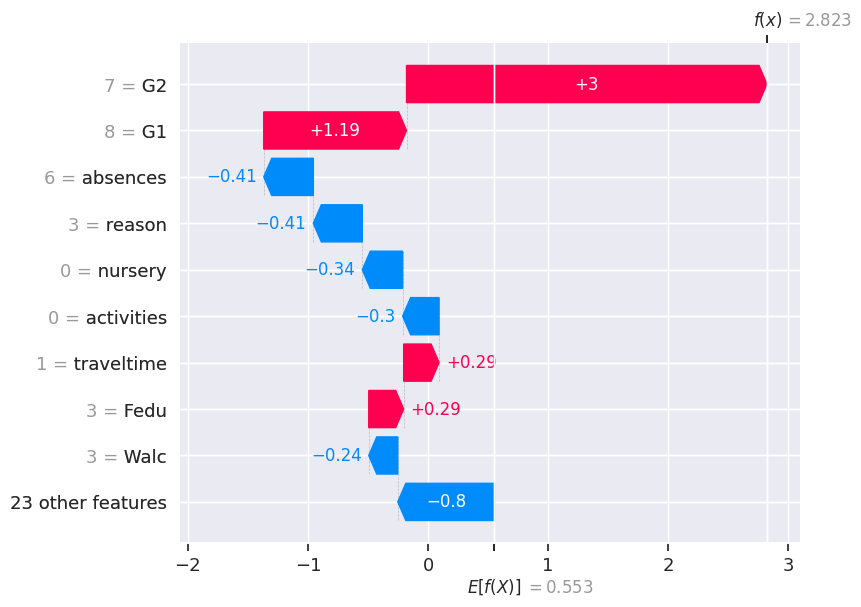

In [12]:
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# 1. Global bar chart
print("Global SHAP Feature Importance:")
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean |SHAP Value| — Global Feature Importance')
plt.tight_layout()
plt.show()

# 2. Beeswarm plot
print("SHAP Beeswarm — Feature Impact Direction:")
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — At-Risk Prediction')
plt.tight_layout()
plt.show()

# 3. Per-student waterfall for the first predicted at-risk student
at_risk_idx = np.where(y_pred_test == 1)[0]
if len(at_risk_idx) > 0:
    idx = at_risk_idx[0]
    print(f"Per-Student SHAP — Student #{idx}  |  Risk Score: {y_proba_test[idx]:.1%}")
    try:
        shap_exp = shap.Explanation(
            values=shap_values[idx],
            base_values=float(explainer.expected_value),
            data=X_test.values[idx],
            feature_names=X_test.columns.tolist()
        )
        shap.plots.waterfall(shap_exp)
    except Exception:
        sv     = pd.Series(shap_values[idx], index=X_test.columns).sort_values()
        colors = ['#e74c3c' if v > 0 else '#27ae60' for v in sv]
        plt.figure(figsize=(10, 7))
        sv.plot(kind='barh', color=colors)
        plt.axvline(0, color='black', linewidth=0.8)
        plt.xlabel('SHAP Value (positive = increases at-risk prediction)')
        plt.title(f'Student #{idx} — Risk Factor Contributions')
        plt.tight_layout()
        plt.show()

In [13]:
def generate_interventions(student_row, shap_row, feature_names, top_n=5):
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap'   : shap_row,
        'value'  : student_row
    }).sort_values('shap', ascending=False)

    top_risk = shap_df[shap_df['shap'] > 0].head(top_n)

    rules = {
        'absences'  : lambda v: v > 6,
        'failures'  : lambda v: v >= 1,
        'G1'        : lambda v: v < 10,
        'G2'        : lambda v: v < 10,
        'studytime' : lambda v: v <= 1,
        'Dalc'      : lambda v: v >= 3,
        'Walc'      : lambda v: v >= 3,
        'health'    : lambda v: v <= 2,
        'famrel'    : lambda v: v <= 2,
        'goout'     : lambda v: v >= 4,
    }

    messages = {
        'absences'  : 'High absences detected — Schedule mandatory attendance review with advisor.',
        'failures'  : 'Prior academic failures — Assign subject mentor and remedial support.',
        'G1'        : 'Low Period 1 grade — Initiate early intervention with class teacher.',
        'G2'        : 'Low Period 2 grade — Enrol in supplementary tutoring before final exams.',
        'studytime' : 'Very low study time — Provide structured weekly study plan.',
        'Dalc'      : 'High weekday alcohol use — Refer to student counselling centre.',
        'Walc'      : 'High weekend alcohol use — Refer to student counselling centre.',
        'health'    : 'Poor health status — Direct to campus medical services.',
        'famrel'    : 'Poor family relations — Connect with student support services.',
        'goout'     : 'Very high social outings — Recommend time-management workshop.',
    }

    plans = []
    for _, row in top_risk.iterrows():
        feat, val = row['feature'], row['value']
        if feat in rules and rules[feat](val):
            plans.append(messages[feat])

    return plans if plans else ['No major risk factors detected. Continue regular monitoring.']


feature_names = X_test.columns.tolist()
X_test_arr    = X_test.values
at_risk_list  = np.where(y_pred_test == 1)[0][:5]

print("=" * 65)
print("      FAILSAFE — PERSONALISED INTERVENTION REPORTS")
print("=" * 65)

for idx in at_risk_list:
    score = y_proba_test[idx]
    plans = generate_interventions(X_test_arr[idx], shap_values[idx], feature_names)
    print()
    print(f"Student #{idx}  |  Risk Score: {score:.1%}")
    print("-" * 65)
    for plan in plans:
        print(f"  > {plan}")

print()
print("=" * 65)

      FAILSAFE — PERSONALISED INTERVENTION REPORTS

Student #0  |  Risk Score: 94.4%
-----------------------------------------------------------------
  > Low Period 2 grade — Enrol in supplementary tutoring before final exams.
  > Low Period 1 grade — Initiate early intervention with class teacher.

Student #5  |  Risk Score: 99.5%
-----------------------------------------------------------------
  > Low Period 2 grade — Enrol in supplementary tutoring before final exams.
  > Low Period 1 grade — Initiate early intervention with class teacher.

Student #11  |  Risk Score: 99.4%
-----------------------------------------------------------------
  > Low Period 2 grade — Enrol in supplementary tutoring before final exams.
  > Low Period 1 grade — Initiate early intervention with class teacher.
  > Very high social outings — Recommend time-management workshop.
  > Prior academic failures — Assign subject mentor and remedial support.

Student #13  |  Risk Score: 93.6%
----------------------

In [14]:
bundle = {
    'model'         : final_model,
    'encoders'      : encoders,
    'feature_names' : X_test.columns.tolist(),
    'explainer'     : explainer,
    'best_params'   : best_params,
}

with open('failsafe_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

files.download('failsafe_model.pkl')
print("failsafe_model.pkl saved and downloading.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

failsafe_model.pkl saved and downloading.
